<div style="
    display: inline-flex;
    align-items: center;
    justify-content: center;
    border-radius: 14px;
    background: linear-gradient(135deg, #ff9966, #ff5e62);
    font-size: 2.2rem;
    color: #ffffff;
    font-weight: 800;
    padding: 18px 40px;
    text-align: center;
    border: 1px solid rgba(255,255,255,0.3);
    backdrop-filter: blur(8px);
    box-shadow: 
        0 10px 25px rgba(0,0,0,0.25),
        inset 0 0 15px rgba(255,255,255,0.2);
    letter-spacing: 1.5px;
    text-shadow: 0 2px 6px rgba(0,0,0,0.4);
    transition: all 0.3s ease;
    cursor: pointer;
">
    Divorce Prediction ⚭
</div>

<style>
.section-badge {
    display: inline-flex;
    align-items: center;
    gap: 10px;
    border-radius: 50px;
    background: linear-gradient(135deg, #4E5E91, #2E3A66);
    color: #ffffff;
    padding: 12px 30px;
    font-weight: 700;
    font-size: 1rem;
    letter-spacing: 0.5px;
    box-shadow: 
        0 6px 18px rgba(0,0,0,0.25),
        inset 0 0 10px rgba(255,255,255,0.1);
    transition: all 0.25s ease;
    cursor: default;
}

.section-badge:hover {
    transform: translateY(-3px);
    box-shadow: 
        0 10px 25px rgba(0,0,0,0.35),
        0 0 15px rgba(78,94,145,0.6);
}

.section-badge span {
    background: rgba(255,255,255,0.15);
    padding: 6px 14px;
    border-radius: 30px;
    font-weight: 800;
}
</style>

<div class="section-badge">
    <span>1</span>
    Data Loading and Cleaning
</div>

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [2]:
file = 'divorce_df.csv'
df = pd.read_csv(file)

df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_at_marriage            5000 non-null   int64  
 1   marriage_duration_years    5000 non-null   int64  
 2   num_children               5000 non-null   int64  
 3   education_level            5000 non-null   object 
 4   employment_status          5000 non-null   object 
 5   combined_income            5000 non-null   int64  
 6   religious_compatibility    5000 non-null   object 
 7   cultural_background_match  5000 non-null   int64  
 8   communication_score        5000 non-null   float64
 9   conflict_frequency         5000 non-null   int64  
 10  conflict_resolution_style  5000 non-null   object 
 11  financial_stress_level     5000 non-null   float64
 12  mental_health_issues       5000 non-null   int64  
 13  infidelity_occurred        5000 non-null   int64

In [3]:
df.head()

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,1,5.536016,3,...,0,0,0,8.428183,5,Love,1,0,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,1,5.810172,3,...,0,1,0,5.297221,1,Love,1,0,6.769384,1
2,31,6,0,High School,Part-time,69441,Same Religion,0,6.088146,3,...,0,0,0,5.887066,1,Arranged,1,0,5.532866,1
3,35,3,2,Bachelor,Full-time,69513,Not Religious,1,6.212046,3,...,0,0,0,5.263555,5,Love,1,0,3.491264,0
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,1,4.826262,1,...,0,0,1,5.771259,4,Love,1,0,10.000000,1


In [4]:
df_columns = df.columns.tolist()
print(df_columns)

['age_at_marriage', 'marriage_duration_years', 'num_children', 'education_level', 'employment_status', 'combined_income', 'religious_compatibility', 'cultural_background_match', 'communication_score', 'conflict_frequency', 'conflict_resolution_style', 'financial_stress_level', 'mental_health_issues', 'infidelity_occurred', 'counseling_attended', 'social_support', 'shared_hobbies_count', 'marriage_type', 'pre_marital_cohabitation', 'domestic_violence_history', 'trust_score', 'divorced']


In [5]:
love_marriage = df[df['marriage_type'].str.lower() == 'love'].copy()
love_marriage.shape
love_marriage.head()

love_marriage_divorced = love_marriage[love_marriage['divorced'] == 1]
love_marriage_divorced.shape
love_marriage_divorced.head()

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,1,5.536016,3,...,0,0,0,8.428183,5,Love,1,0,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,1,5.810172,3,...,0,1,0,5.297221,1,Love,1,0,6.769384,1
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,1,4.826262,1,...,0,0,1,5.771259,4,Love,1,0,10.000000,1
7,31,17,1,High School,Unemployed,59491,Not Religious,1,6.613021,4,...,0,0,0,8.709813,2,Love,0,0,7.010559,1
18,23,25,1,High School,Full-time,98935,Same Religion,0,6.728135,3,...,0,0,0,5.608493,4,Love,0,0,7.759189,1


In [6]:
arranged_marriage = df[df['marriage_type'].str.lower() == 'arranged'].copy()
arranged_marriage.shape
arranged_marriage.head()

arranged_marriage_divorced = arranged_marriage[arranged_marriage['divorced'] == 1]
arranged_marriage_divorced.shape
arranged_marriage_divorced.head()

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
2,31,6,0,High School,Part-time,69441,Same Religion,0,6.088146,3,...,0,0,0,5.887066,1,Arranged,1,0,5.532866,1
9,30,1,0,PhD,Full-time,46819,Same Religion,1,3.612109,1,...,1,0,0,5.939285,1,Arranged,1,0,8.750676,1
12,29,9,3,Bachelor,Full-time,99575,Same Religion,1,6.471661,2,...,0,0,1,5.000274,4,Arranged,0,0,3.203307,1
14,19,1,3,Bachelor,Homemaker,67524,Same Religion,1,3.162700,4,...,0,0,1,8.525429,4,Arranged,0,0,2.182855,1
15,25,7,2,High School,Full-time,58690,Same Religion,1,8.412019,0,...,0,0,0,7.219046,0,Arranged,1,0,8.568000,1


<style>
.section-badge {
    display: inline-flex;
    align-items: center;
    gap: 10px;
    border-radius: 50px;
    background: linear-gradient(135deg, #4E5E91, #2E3A66);
    color: #ffffff;
    padding: 12px 30px;
    font-weight: 700;
    font-size: 1rem;
    letter-spacing: 0.5px;
    box-shadow: 
        0 6px 18px rgba(0,0,0,0.25),
        inset 0 0 10px rgba(255,255,255,0.1);
    transition: all 0.25s ease;
    cursor: default;
}

.section-badge:hover {
    transform: translateY(-3px);
    box-shadow: 
        0 10px 25px rgba(0,0,0,0.35),
        0 0 15px rgba(78,94,145,0.6);
}

.section-badge span {
    background: rgba(255,255,255,0.15);
    padding: 6px 14px;
    border-radius: 30px;
    font-weight: 800;
}
</style>

<div class="section-badge">
    <span>2</span>
    Data Analysis and Visualization
</div>

In [7]:
mean_MarriageDuration = df[df['divorced'] == 1]['marriage_duration_years'].mean()
print(f"Average Marriage Duration (Arranged & Divorced): {mean_MarriageDuration:.2f} years")

mean_LoveMarriageDuration = love_marriage_divorced['marriage_duration_years'].mean()
print(f"Average Marriage Duration for Love Marriages: {mean_LoveMarriageDuration:.2f} years")

mean_ArrangedMarriageDuration = arranged_marriage_divorced['marriage_duration_years'].mean()
print(f"Average Marriage Duration for Arranged Marriages: {mean_ArrangedMarriageDuration:.2f} years")

Average Marriage Duration (Arranged & Divorced): 9.28 years
Average Marriage Duration for Love Marriages: 9.31 years
Average Marriage Duration for Arranged Marriages: 9.15 years


In [8]:
def to_percentage(series):
    return (series.mean() * 100).round(1)

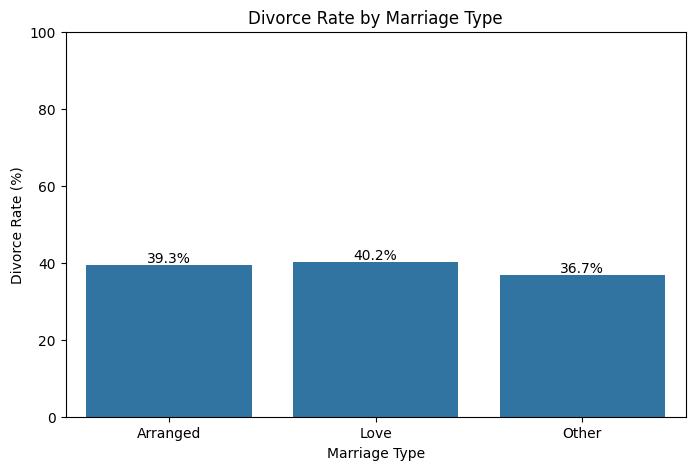

In [9]:
marriage_divorce = (
    df.groupby("marriage_type")["divorced"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="divorce_rate_%")
)

plt.figure(figsize=(8,5))
ax = sns.barplot(data=marriage_divorce,
                 x="marriage_type",
                 y="divorce_rate_%")

plt.title("Divorce Rate by Marriage Type")
plt.ylabel("Divorce Rate (%)")
plt.xlabel("Marriage Type")
plt.ylim(0,100)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.1f}%",
                (p.get_x() + p.get_width()/2, height),
                ha="center", va="bottom", fontsize=10)

plt.show()

Surprisingly, contrary to assumptions, the divorce rate according to the type of marriage differs only by decimal points, and even marriages based on love are more prone to divorce.

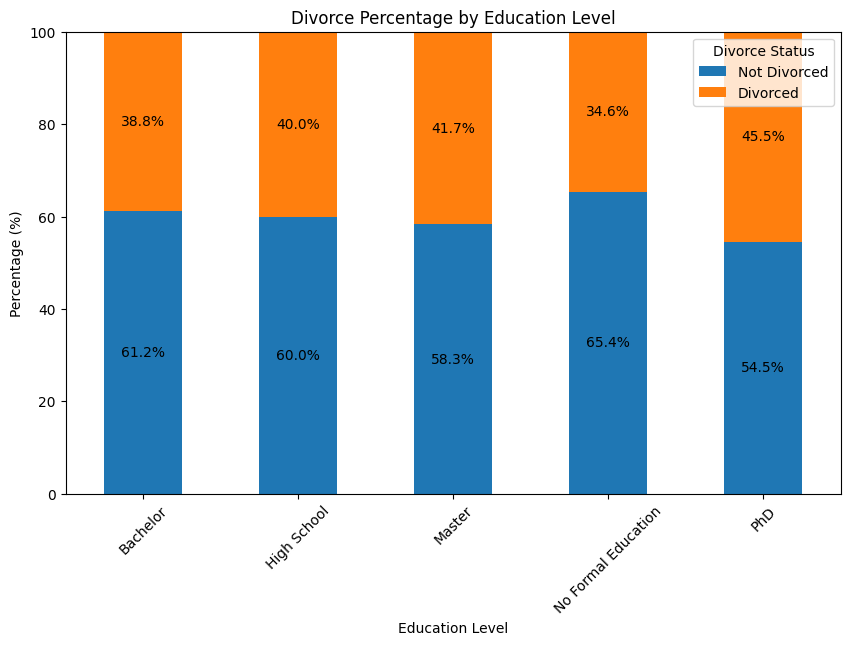

In [10]:
edu_divorce = (
    pd.crosstab(df["education_level"], df["divorced"], normalize="index")
    .mul(100)
    .round(1)
)

ax = edu_divorce.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Divorce Percentage by Education Level")
plt.ylabel("Percentage (%)")
plt.xlabel("Education Level")
plt.legend(["Not Divorced", "Divorced"], title="Divorce Status")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.ylim(0,100)
plt.show()

People with higher levels of education are more likely to divorce. As can be seen in the graph, the higher the level of education, the greater the likelihood that their marriage will end in divorce.

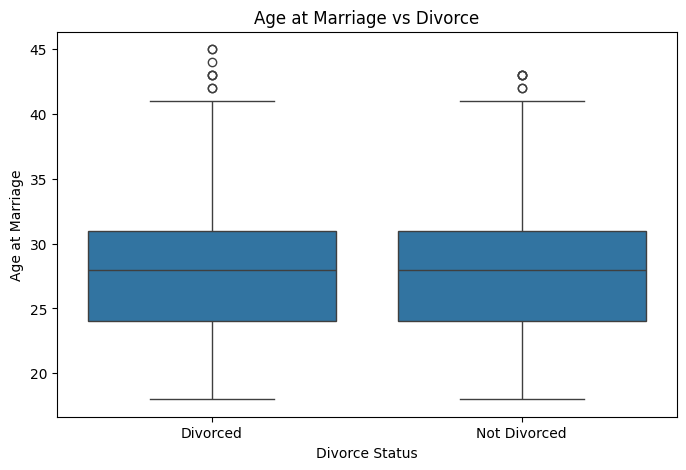

In [11]:
df["divorced_label"] = df["divorced"].map({0:"Not Divorced", 1:"Divorced"})

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="divorced_label", y="age_at_marriage")

plt.title("Age at Marriage vs Divorce")
plt.xlabel("Divorce Status")
plt.ylabel("Age at Marriage")
plt.show()

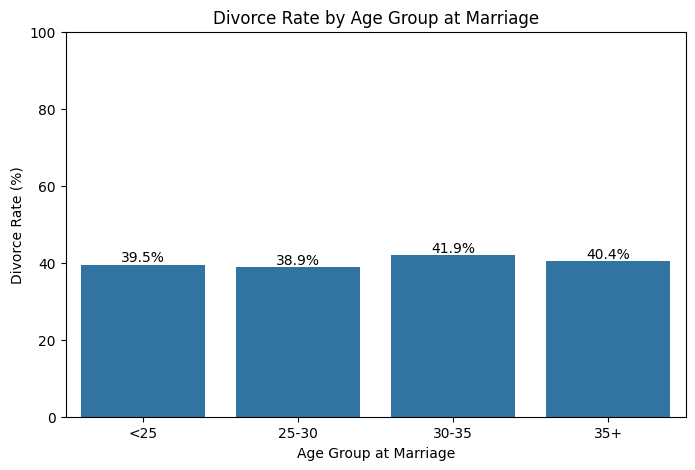

In [12]:
bins = [0,25,30,35,100]
labels = ["<25","25-30","30-35","35+"]

df["age_group"] = pd.cut(df["age_at_marriage"], bins=bins, labels=labels)

age_divorce = (
    df.groupby("age_group")["divorced"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="divorce_rate_%")
)

plt.figure(figsize=(8,5))
ax = sns.barplot(data=age_divorce,
                 x="age_group",
                 y="divorce_rate_%")

plt.title("Divorce Rate by Age Group at Marriage")
plt.ylabel("Divorce Rate (%)")
plt.xlabel("Age Group at Marriage")
plt.ylim(0,100)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.1f}%",
                (p.get_x() + p.get_width()/2, height),
                ha="center", va="bottom", fontsize=10)

plt.show()

Apparently, the older the age at which the marriage took place, the greater the likelihood of divorce. Surprisingly, however, younger marriages divorce slightly more than those who married between the ages of 25 and 30.

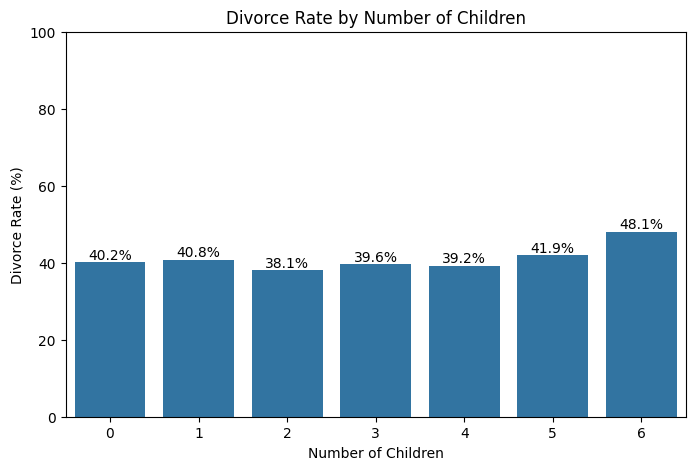

In [13]:
children_divorce_percent = (
    df.groupby("num_children")["divorced"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="divorce_rate_%")
)

plt.figure(figsize=(8,5))
ax = sns.barplot(data=children_divorce_percent,
                x="num_children",
                y="divorce_rate_%")

plt.title("Divorce Rate by Number of Children")
plt.ylabel("Divorce Rate (%)")
plt.xlabel("Number of Children")
plt.ylim(0,100)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.1f}%",
                (p.get_x() + p.get_width()/2, height),
                ha="center", va="bottom", fontsize=10)

plt.show()

The distribution of divorces by number of children remains uniform, although it shows that marriages with six children are more likely to end in divorce.

  religious_compatibility  divorce_rate_%
0      Different Religion            41.0
1           Not Religious            38.1
2           Same Religion            40.0


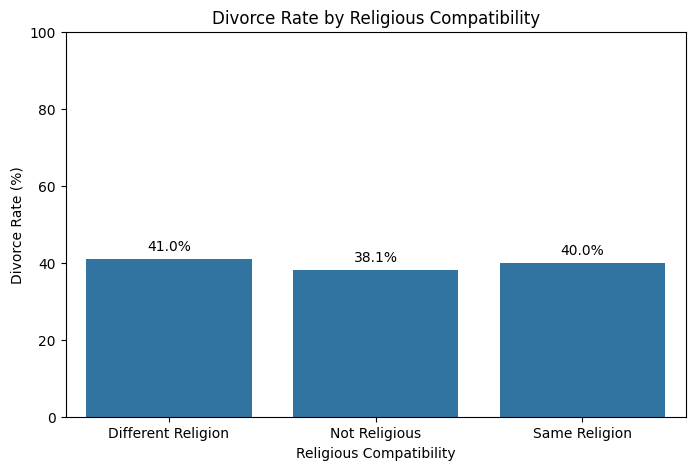

In [14]:
religion_percent = (
    df.groupby("religious_compatibility")["divorced"]
    .apply(lambda x: round(x.mean()*100,1))
    .reset_index(name="divorce_rate_%")
)

print(religion_percent)

plt.figure(figsize=(8,5))
sns.barplot(data=religion_percent, x="religious_compatibility", y="divorce_rate_%")
plt.title("Divorce Rate by Religious Compatibility")
plt.xlabel("Religious Compatibility")
plt.ylabel("Divorce Rate (%)")
plt.ylim(0,100)
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f"{height:.1f}%", 
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom", fontsize=10, xytext=(0,4), textcoords="offset points")
plt.show()

Apparently, different religions can be grounds for divorce.

   domestic_violence_history  divorce_rate_%
0                          0            38.9
1                          1            56.7


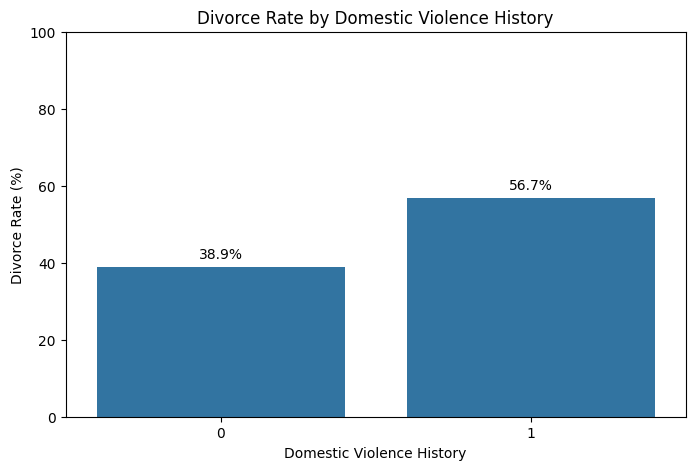

In [15]:
violence_percent = (
    df.groupby("domestic_violence_history")["divorced"]
    .apply(lambda x: round(x.mean()*100,1))
    .reset_index(name="divorce_rate_%")
)

print(violence_percent)

plt.figure(figsize=(8,5))
sns.barplot(data=violence_percent, x="domestic_violence_history", y ="divorce_rate_%")
plt.title("Divorce Rate by Domestic Violence History")  
plt.xlabel("Domestic Violence History")
plt.ylabel("Divorce Rate (%)")
plt.ylim(0,100)
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f"{height:.1f}%", 
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom", fontsize=10, xytext=(0,4), textcoords="offset points")
plt.show()

Domestic violence has been shown to be a major cause of divorce, as more than half of divorced couples have had incidents of this type in their history. However, it is worrying that it also exists in couples who have not divorced.

   infidelity_occurred  divorce_rate_%
0                    0            38.3
1                    1            48.6


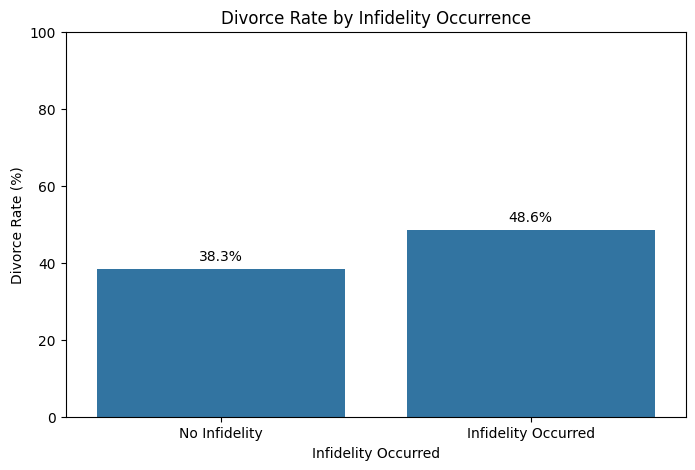

In [16]:
infidelity_percent = (
    df.groupby("infidelity_occurred")["divorced"]
    .apply(lambda x: round(x.mean()*100,1))
    .reset_index(name="divorce_rate_%")
)

print(infidelity_percent)
plt.figure(figsize=(8,5))
sns.barplot(data=infidelity_percent, x="infidelity_occurred", y="divorce_rate_%")
plt.title("Divorce Rate by Infidelity Occurrence")
plt.xlabel("Infidelity Occurred")
plt.ylabel("Divorce Rate (%)")
plt.ylim(0,100)
plt.gca().set_xticklabels(["No Infidelity", "Infidelity Occurred"])
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f"{height:.1f}%", 
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom", fontsize=10, xytext=(0,4), textcoords="offset points")
plt.show()

Less than half of divorced couples have a history of infidelity.

  conflict_resolution_style  divorce_rate_%
0                Aggressive            40.1
1                  Avoidant            37.8
2             Collaborative            39.9
3                   Passive            42.6


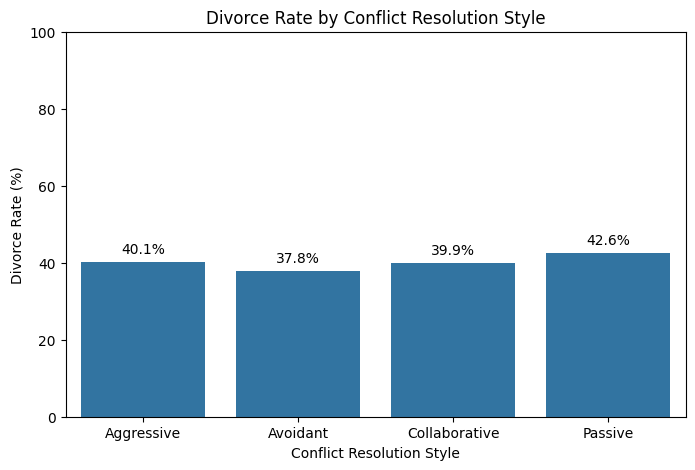

In [17]:
conflict_percent = (
    df.groupby("conflict_resolution_style")["divorced"]
    .apply(lambda x: round(x.mean()*100,1))
    .reset_index(name="divorce_rate_%")
)

print(conflict_percent)

plt.figure(figsize=(8,5))
sns.barplot(data=conflict_percent, x="conflict_resolution_style", y="divorce_rate_%")
plt.title("Divorce Rate by Conflict Resolution Style")
plt.xlabel("Conflict Resolution Style")
plt.ylabel("Divorce Rate (%)")
plt.ylim(0,100)
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f"{height:.1f}%", 
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom", fontsize=10, xytext=(0,4), textcoords="offset points")
plt.show()

In marriages with aggressive or passive conflict resolution styles, there is a greater tendency toward divorce.

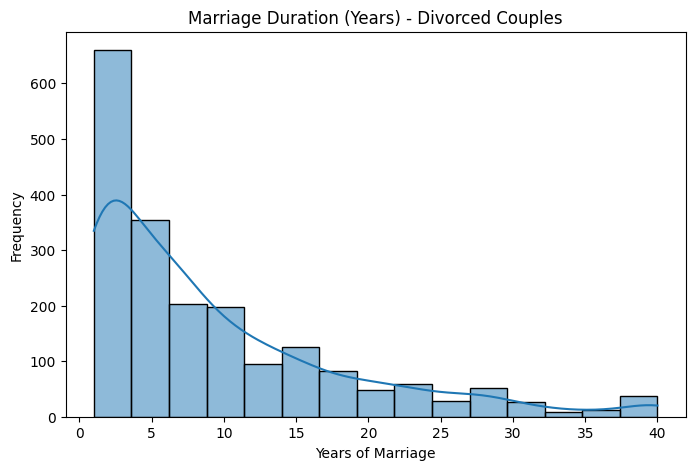

In [18]:
divorced_df = df[df["divorced"] == 1]

plt.figure(figsize=(8,5))
sns.histplot(divorced_df["marriage_duration_years"], bins=15, kde=True)

plt.title("Marriage Duration (Years) - Divorced Couples")
plt.xlabel("Years of Marriage")
plt.ylabel("Frequency")
plt.show()

The fewer years of marriage, the greater the likelihood of divorce. Longer marriages probably did not consider divorce as often as shorter marriages.

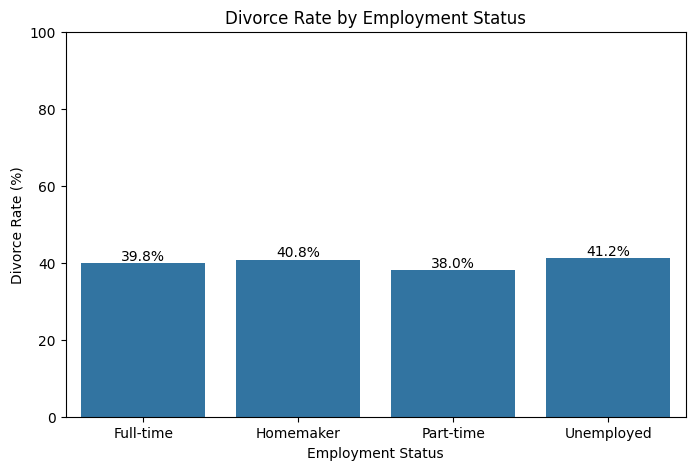

In [19]:
employment_divorce = (
    df.groupby("employment_status")["divorced"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="divorce_rate_%")
)

plt.figure(figsize=(8,5))
ax = sns.barplot(data=employment_divorce,
                 x="employment_status",
                 y="divorce_rate_%")

plt.title("Divorce Rate by Employment Status")
plt.ylabel("Divorce Rate (%)")
plt.xlabel("Employment Status")
plt.ylim(0,100)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")

plt.show()

It is most likely that due to financial stress, many couples have divorced, since marriages where there is unemployment or where no income is generated have a higher divorce rate. However, there is also a tendency for divorce among those who work full-time.

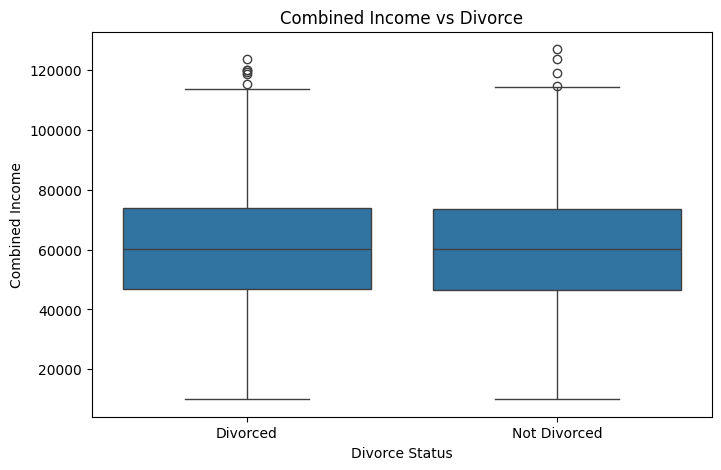

In [20]:
df["divorced_label"] = df["divorced"].map({0:"Not Divorced",1:"Divorced"})

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="divorced_label", y="combined_income")

plt.title("Combined Income vs Divorce")
plt.xlabel("Divorce Status")
plt.ylabel("Combined Income")
plt.show()

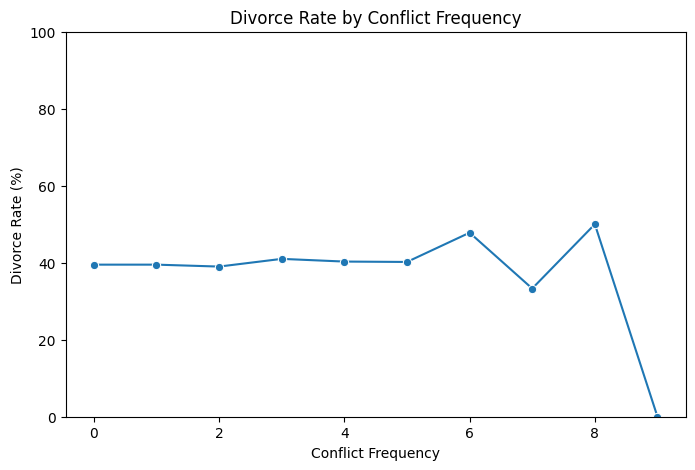

In [21]:
conflict_divorce = (
    df.groupby("conflict_frequency")["divorced"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="divorce_rate_%")
)

plt.figure(figsize=(8,5))
sns.lineplot(data=conflict_divorce,
             x="conflict_frequency",
             y="divorce_rate_%",
             marker="o")

plt.title("Divorce Rate by Conflict Frequency")
plt.ylabel("Divorce Rate (%)")
plt.xlabel("Conflict Frequency")
plt.ylim(0,100)
plt.show()

To no one's surprise, couples with more conflicts tend to divorce.

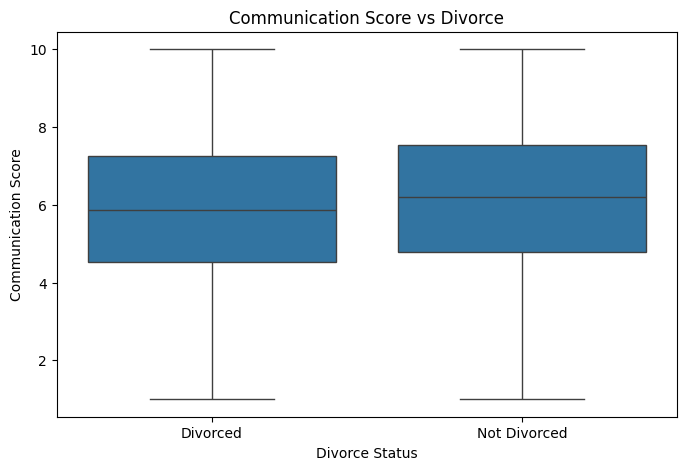

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="divorced_label", y="communication_score")

plt.title("Communication Score vs Divorce")
plt.xlabel("Divorce Status")
plt.ylabel("Communication Score")
plt.show()

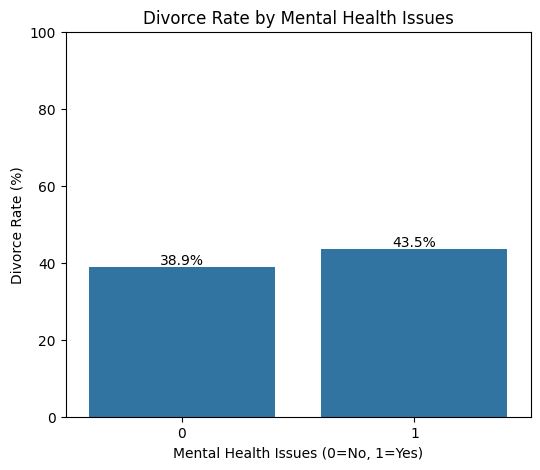

In [23]:
mental_divorce = (
    df.groupby("mental_health_issues")["divorced"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="divorce_rate_%")
)

plt.figure(figsize=(6,5))
ax = sns.barplot(data=mental_divorce,
                 x="mental_health_issues",
                 y="divorce_rate_%")

plt.title("Divorce Rate by Mental Health Issues")
plt.ylabel("Divorce Rate (%)")
plt.xlabel("Mental Health Issues (0=No, 1=Yes)")
plt.ylim(0,100)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")

plt.show()

There is a higher tendency for divorce among couples where there are mental health issues.

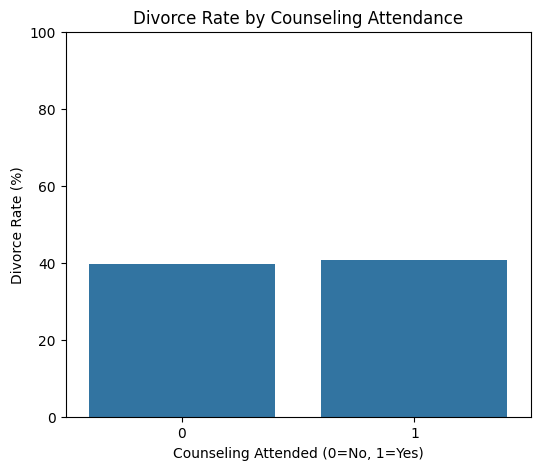

In [24]:
counseling_divorce = (
    df.groupby("counseling_attended")["divorced"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="divorce_rate_%")
)

plt.figure(figsize=(6,5))
sns.barplot(data=counseling_divorce,
            x="counseling_attended",
            y="divorce_rate_%")

plt.title("Divorce Rate by Counseling Attendance")
plt.ylabel("Divorce Rate (%)")
plt.xlabel("Counseling Attended (0=No, 1=Yes)")
plt.ylim(0,100)
plt.show()

Actually, there is little difference between divorced couples who did or did not receive help from a marriage counselor.

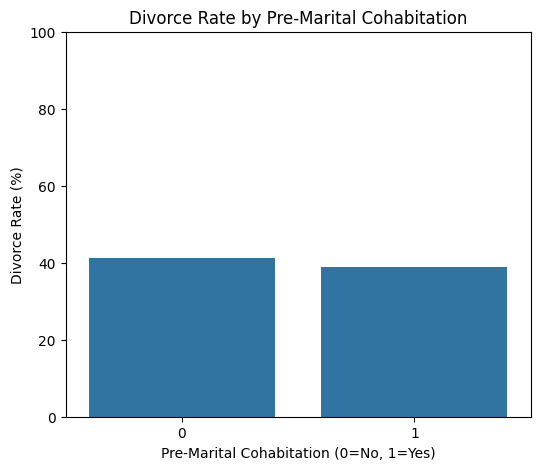

In [25]:
cohab_divorce = (
    df.groupby("pre_marital_cohabitation")["divorced"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="divorce_rate_%")
)

plt.figure(figsize=(6,5))
sns.barplot(data=cohab_divorce,
            x="pre_marital_cohabitation",
            y="divorce_rate_%")

plt.title("Divorce Rate by Pre-Marital Cohabitation")
plt.ylabel("Divorce Rate (%)")
plt.xlabel("Pre-Marital Cohabitation (0=No, 1=Yes)")
plt.ylim(0,100)
plt.show()

Couples who did not live together before marriage are more likely to divorce.

In [26]:
numeric_cols = [
    'age_at_marriage', 'marriage_duration_years', 'num_children',
    'combined_income', 'communication_score', 'conflict_frequency',
    'financial_stress_level', 'social_support',
    'shared_hobbies_count', 'trust_score'
]

profile = (
    df.groupby("divorced")[numeric_cols]
    .mean()
    .round(2)
)

print(profile)

          age_at_marriage  marriage_duration_years  num_children  \
divorced                                                           
0                   27.55                     9.10          1.56   
1                   27.63                     9.28          1.54   

          combined_income  communication_score  conflict_frequency  \
divorced                                                             
0                60029.54                 6.16                2.00   
1                60508.04                 5.86                2.03   

          financial_stress_level  social_support  shared_hobbies_count  \
divorced                                                                 
0                           4.94            6.02                  3.00   
1                           5.27            5.89                  2.94   

          trust_score  
divorced               
0                6.11  
1                5.91  


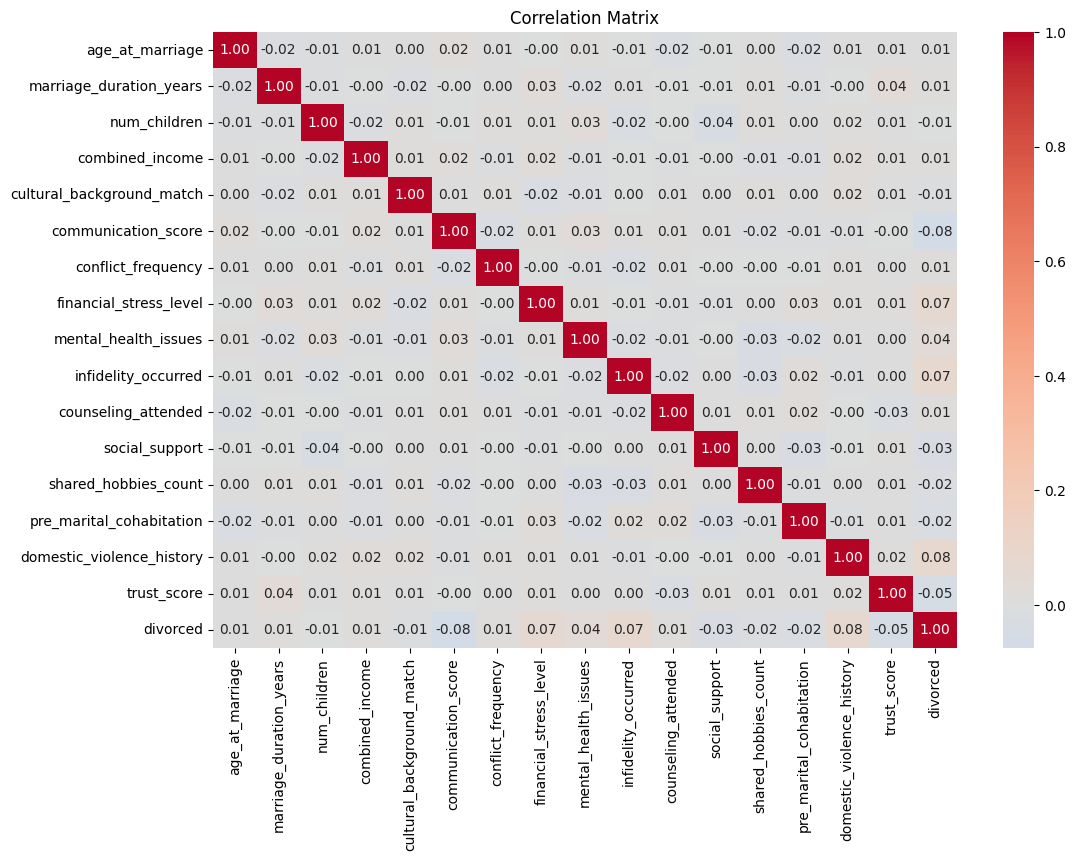

In [27]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0)

plt.title("Correlation Matrix")
plt.show()

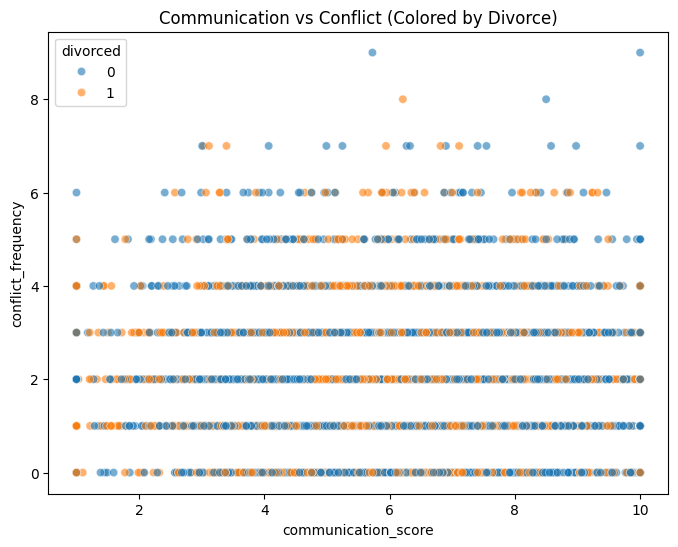

In [28]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,
                x="communication_score",
                y="conflict_frequency",
                hue="divorced",
                alpha=0.6)

plt.title("Communication vs Conflict (Colored by Divorce)")
plt.show()

<style>
.section-badge {
    display: inline-flex;
    align-items: center;
    gap: 10px;
    border-radius: 50px;
    background: linear-gradient(135deg, #4E5E91, #2E3A66);
    color: #ffffff;
    padding: 12px 30px;
    font-weight: 700;
    font-size: 1rem;
    letter-spacing: 0.5px;
    box-shadow: 
        0 6px 18px rgba(0,0,0,0.25),
        inset 0 0 10px rgba(255,255,255,0.1);
    transition: all 0.25s ease;
    cursor: default;
}

.section-badge:hover {
    transform: translateY(-3px);
    box-shadow: 
        0 10px 25px rgba(0,0,0,0.35),
        0 0 15px rgba(78,94,145,0.6);
}

.section-badge span {
    background: rgba(255,255,255,0.15);
    padding: 6px 14px;
    border-radius: 30px;
    font-weight: 800;
}
</style>

<div class="section-badge">
    <span>3</span>
    Data Prediction
</div>

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X = df[numeric_cols]
y = df["divorced"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

tree = DecisionTreeClassifier(max_depth=4)
tree.fit(X_train, y_train)

importance = pd.Series(tree.feature_importances_, index=numeric_cols)
print(importance.sort_values(ascending=False))

trust_score                0.284990
communication_score        0.262797
marriage_duration_years    0.156383
financial_stress_level     0.144924
social_support             0.082830
age_at_marriage            0.068076
num_children               0.000000
combined_income            0.000000
conflict_frequency         0.000000
shared_hobbies_count       0.000000
dtype: float64


In [30]:
df["risk_group"] = pd.qcut(df["trust_score"], 4, labels=["Low","Medium-Low","Medium-High","High"])

risk_analysis = df.groupby("risk_group")["divorced"].mean().mul(100)

print(risk_analysis)

risk_group
Low            43.52
Medium-Low     40.16
Medium-High    37.84
High           37.76
Name: divorced, dtype: float64


In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

coefficients = pd.Series(model.coef_[0], index=numeric_cols)
print(coefficients.sort_values())

communication_score       -0.082846
trust_score               -0.071344
social_support            -0.040606
shared_hobbies_count      -0.037618
num_children              -0.015204
age_at_marriage           -0.001451
combined_income            0.000002
marriage_duration_years    0.002636
conflict_frequency         0.004391
financial_stress_level     0.055151
dtype: float64
